# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Kurs/Python/data/yulu_rental.csv')

In [6]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [9]:
df.shape

(10886, 19)

In [11]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day,week,weekday_num,year,month,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.0,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,9.992559,25.917784,3.013963,2011.501929,6.521495,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,5.476608,15.017269,2.004585,0.500019,3.444373,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,2011.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,5.000000,14.0,1.000000,2011.000000,4.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,10.000000,26.0,3.000000,2012.000000,7.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,15.000000,40.0,5.000000,2012.000000,10.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,19.000000,52.0,6.000000,2012.000000,12.000000,23.000000


In [12]:
df.index.to_series().diff()

,datetime
datetime,
2011-01-01 00:00:00,NaT
2011-01-01 01:00:00,0 days 01:00:00
2011-01-01 02:00:00,0 days 01:00:00
2011-01-01 03:00:00,0 days 01:00:00
2011-01-01 04:00:00,0 days 01:00:00
...,...
2012-12-19 19:00:00,0 days 01:00:00
2012-12-19 20:00:00,0 days 01:00:00
2012-12-19 21:00:00,0 days 01:00:00


In [13]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [14]:
df.tail()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21
2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012-12-19,19,51,2,Wednesday,2012,12,22
2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012-12-19,19,51,2,Wednesday,2012,12,23


Висновок:
Отже, дані містять 10886 рядків і 19 колонок (разом з додатковими колонками, створеними на основі дати).
Рівень деталізацї - щогодинний.
Часові рамки - від початку 2011 року до 19 грудня 2012.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [17]:
daily_rental_count = df['count'].resample('D').sum()

In [18]:
daily_rental_count

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


<Axes: title={'center': 'Динаміка оренди велосипедів'}, xlabel='day'>

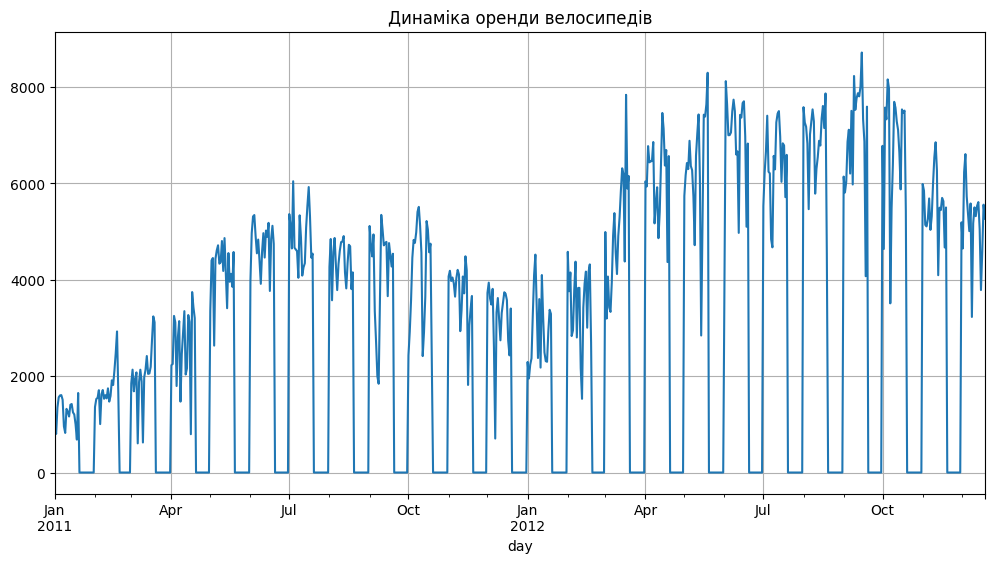

In [20]:
daily_rental_count.plot(
    kind = 'line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True,
    xlabel= 'day'
)

In [22]:
daily_rental_count[daily_rental_count == 0]

,count
datetime,
2011-01-20,0
2011-01-21,0
2011-01-22,0
2011-01-23,0
2011-01-24,0
...,...
2012-11-26,0
2012-11-27,0
2012-11-28,0


In [23]:
daily_rental_count.head(20)

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
2011-01-06,1606
2011-01-07,1510
2011-01-08,959
2011-01-09,822


In [37]:
df[df['date'].isin(
    pd.to_datetime(['2011-01-20', '2011-01-22', '2011-01-23']).date
)]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,


In [38]:
monthly_rentals = df['count'].resample('M').sum()

/tmp/ipykernel_897/2006716898.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rentals = df['count'].resample('M').sum()


<Axes: title={'center': 'Динаміка оренди велосипедів по місяцях'}, xlabel='datetime'>

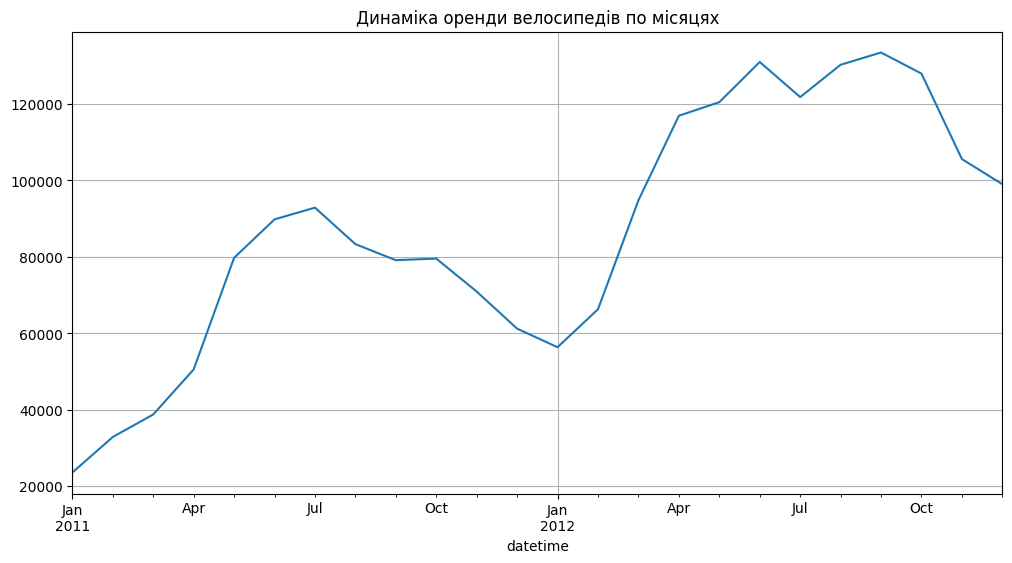

In [39]:
monthly_rentals.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів по місяцях',
    grid=True
)

In [43]:
df.groupby(['year','month'])['count'].mean()

year  month
2011  1         54.645012
      2         73.641256
      3         86.849776
      4        111.026374
      5        174.809211
      6        196.877193
      7        203.614035
      8        182.666667
      9        174.622517
      10       174.773626
      11       155.458333
      12       134.173246
2012  1        124.353201
      2        145.646154
      3        208.276923
      4        257.455947
      5        264.109649
      6        287.186404
      7        267.037281
      8        285.570175
      9        292.598684
      10       280.508772
      11       231.980220
      12       217.054825
Name: count, dtype: float64

<Axes: title={'center': 'Середня кількість оренд за місяцями'}, xlabel='year,month'>

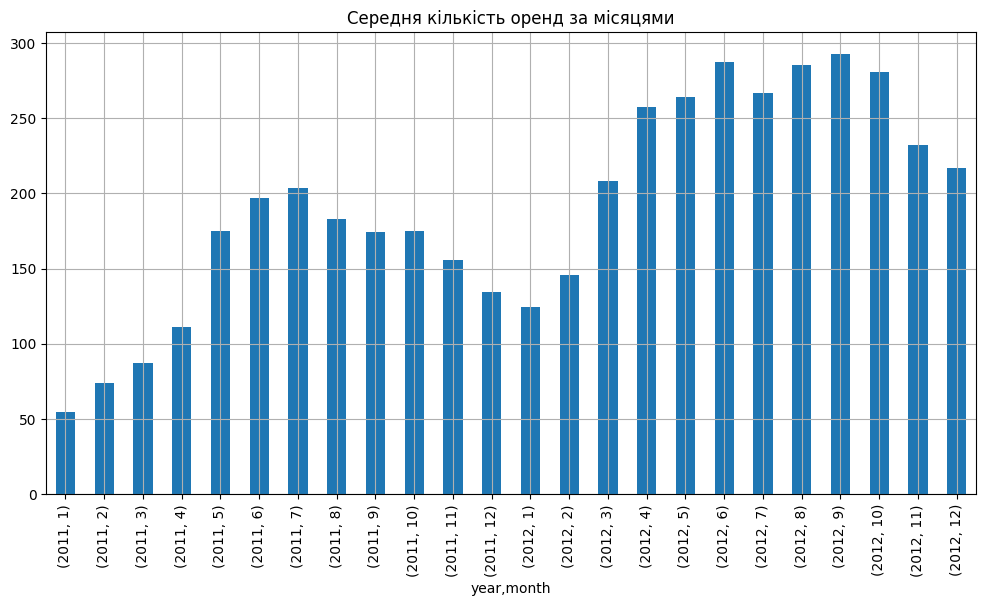

In [45]:
df.groupby(['year','month'])['count'].mean().plot(
    kind='bar',
    figsize=(12, 6),
    title='Середня кількість оренд за місяцями',
    grid=True
)

In [46]:
daily_rental_count.nlargest(10)

,count
datetime,
2012-09-15,8714
2012-05-19,8294
2012-09-09,8227
2012-10-05,8156
2012-06-02,8120
2012-09-14,8009
2012-10-06,7965
2012-09-12,7870
2012-08-18,7865


In [50]:
df[df['date'].isin(
    pd.to_datetime(['2012-09-15']).date
)]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-09-15 00:00:00,3,0,0,1,24.60,28.030,83,7.0015,38,169,207,2012-09-15,15,37,5,Saturday,2012,9,0
2012-09-15 01:00:00,3,0,0,1,24.60,29.545,73,0.0000,8,101,109,2012-09-15,15,37,5,Saturday,2012,9,1
2012-09-15 02:00:00,3,0,0,1,23.78,27.275,78,7.0015,18,75,93,2012-09-15,15,37,5,Saturday,2012,9,2
2012-09-15 03:00:00,3,0,0,1,24.60,29.545,73,16.9979,6,31,37,2012-09-15,15,37,5,Saturday,2012,9,3
2012-09-15 04:00:00,3,0,0,2,24.60,29.545,69,23.9994,3,3,6,2012-09-15,15,37,5,Saturday,2012,9,4
2012-09-15 05:00:00,3,0,0,1,23.78,27.275,60,35.0008,1,15,16,2012-09-15,15,37,5,Saturday,2012,9,5
2012-09-15 06:00:00,3,0,0,1,22.14,25.760,49,27.9993,6,27,33,2012-09-15,15,37,5,Saturday,2012,9,6
2012-09-15 07:00:00,3,0,0,1,22.14,25.760,52,19.0012,10,63,73,2012-09-15,15,37,5,Saturday,2012,9,7
2012-09-15 08:00:00,3,0,0,1,22.96,26.515,49,27.9993,43,169,212,2012-09-15,15,37,5,Saturday,2012,9,8


In [51]:
df[df['date'].isin(
    pd.to_datetime(['2012-05-19']).date
)]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-05-19 00:00:00,2,0,0,1,21.32,25.000,48,7.0015,30,118,148,2012-05-19,19,20,5,Saturday,2012,5,0
2012-05-19 01:00:00,2,0,0,1,20.50,24.240,48,0.0000,20,84,104,2012-05-19,19,20,5,Saturday,2012,5,1
2012-05-19 02:00:00,2,0,0,1,20.50,24.240,51,7.0015,13,56,69,2012-05-19,19,20,5,Saturday,2012,5,2
2012-05-19 03:00:00,2,0,0,1,20.50,24.240,48,7.0015,10,23,33,2012-05-19,19,20,5,Saturday,2012,5,3
2012-05-19 04:00:00,2,0,0,1,19.68,23.485,59,6.0032,6,8,14,2012-05-19,19,20,5,Saturday,2012,5,4
2012-05-19 05:00:00,2,0,0,1,18.86,22.725,67,0.0000,1,11,12,2012-05-19,19,20,5,Saturday,2012,5,5
2012-05-19 06:00:00,2,0,0,1,18.04,21.970,72,6.0032,12,38,50,2012-05-19,19,20,5,Saturday,2012,5,6
2012-05-19 07:00:00,2,0,0,1,18.86,22.725,67,7.0015,28,67,95,2012-05-19,19,20,5,Saturday,2012,5,7
2012-05-19 08:00:00,2,0,0,1,21.32,25.000,52,11.0014,33,162,195,2012-05-19,19,20,5,Saturday,2012,5,8


In [58]:
daily_rental_count[daily_rental_count > 0].nsmallest(10)

,count
datetime,
2011-03-06,605
2011-03-10,623
2011-01-18,683
2011-12-07,705
2011-04-16,795
2011-01-02,801
2011-01-09,822
2011-01-08,959
2011-01-01,985


In [59]:
df[df['date'].isin(
    pd.to_datetime(['2011-03-06']).date
)]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-03-06 00:00:00,1,0,0,2,17.22,21.210,77,23.9994,11,41,52,2011-03-06,6,9,6,Sunday,2011,3,0
2011-03-06 01:00:00,1,0,0,2,17.22,21.210,77,19.0012,12,27,39,2011-03-06,6,9,6,Sunday,2011,3,1
2011-03-06 02:00:00,1,0,0,2,16.40,20.455,82,19.0012,5,27,32,2011-03-06,6,9,6,Sunday,2011,3,2
2011-03-06 03:00:00,1,0,0,2,17.22,21.210,82,19.9995,2,9,11,2011-03-06,6,9,6,Sunday,2011,3,3
2011-03-06 04:00:00,1,0,0,2,17.22,21.210,88,23.9994,0,3,3,2011-03-06,6,9,6,Sunday,2011,3,4
2011-03-06 06:00:00,1,0,0,2,17.22,21.210,94,23.9994,1,1,2,2011-03-06,6,9,6,Sunday,2011,3,6
2011-03-06 07:00:00,1,0,0,3,17.22,21.210,100,30.0026,0,5,5,2011-03-06,6,9,6,Sunday,2011,3,7
2011-03-06 08:00:00,1,0,0,2,16.40,20.455,100,19.9995,1,8,9,2011-03-06,6,9,6,Sunday,2011,3,8
2011-03-06 09:00:00,1,0,0,2,17.22,21.210,100,19.0012,4,18,22,2011-03-06,6,9,6,Sunday,2011,3,9


1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи? - Причиною заломів на графіку є відсутність даних за деякі дні. Тому за дні, коли в датасеті відсутні дані на графіку ми бачимо значення 0. Уникнути цього можна видаливши з датасету пусті рядки.
2. Які загальні тенденції ви бачите на графіку? - На графіку з середньою кількістю орендованих велосипедів за місяцями чітко видно, що кількість орендованих велосипедів в 2012 році зросла порівняно з 2011 роком. Можливо магазин збільшив асортимент і кількість велосипедів або провів рекламні кампанії, що спричинило зріст попиту.
3. Чи помітні якісь сезонні коливання? - Помітно, що в період з квітня по жовтень середня кількість оренди в місяці вища, нід в інші періоди. Це можна пояснити більш сприятливими умовами для велопрогулянок.
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії? - Аномально високі значення, які були наприклад 2012-09-15 та 2012-05-19 можна пояснити тим, що це були вихідні дні з добрими погодними умовами, тому багато як зареєстрованих так і випадкових користувачів орендували велосипеди в ті дні. Аномально низькі значення можна так само пояснити погодніми умовами, як наприклад 2011-03-06 оскільки в той день був туман, що вплинуло на попит.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [60]:
df.groupby(['year', 'season'])['count'].mean()

year  season
2011  1          71.905518
      2         160.940746
      3         186.994872
      4         154.787125
2012  1         159.476889
      2         269.601757
      3         281.735380
      4         243.189466
Name: count, dtype: float64

In [63]:
season_avg = df.groupby(['season'])['count'].mean()

In [64]:
season_avg

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [66]:
season_avg.index = ['Q1', 'Q2', 'Q3', 'Q4']

<Axes: title={'center': 'Середня кількість оренд велосипедів за сезонами'}, xlabel='Сезон', ylabel='Середня кількість оренд'>

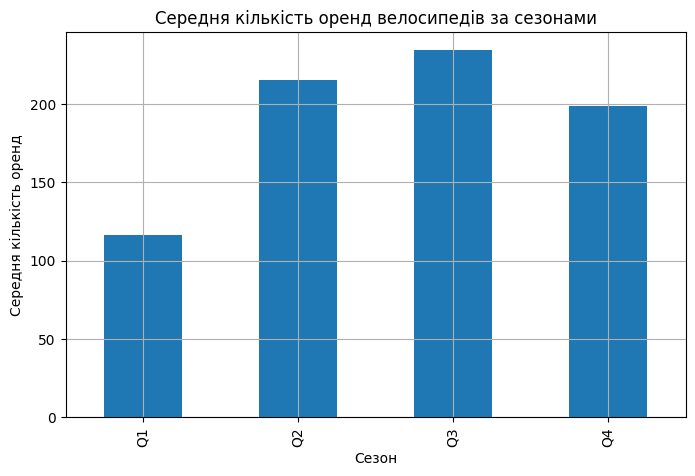

In [67]:
season_avg.plot(
    kind='bar',
    figsize=(8, 5),
    title='Середня кількість оренд велосипедів за сезонами',
    xlabel='Сезон',
    ylabel='Середня кількість оренд',
    grid=True
)

In [68]:
season_avg.max() / season_avg.min()

2.0148749597441986

In [69]:
season_avg.idxmin()

'Q1'

In [70]:
season_avg.idxmax()

'Q3'

1. В який квартал найбільша середня кількість оренди велосипедів? -  В третьому кварталі найбільша середня кількість оренди.
2. Як ви можете пояснити таку сезонну закономірність?- Це можна пояснити сприятливими погодніми умовами і тим, що саме третій квартал є найпопулярнішим періодом для відпусток, а також це період канікул в школах та університетах, що може впливати на попит на оренду в зв'язку з більшою кількістю вільного часу в людей.
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами? - Середня оренда між найпопулярнішим там найменш популярним кварталами відрізняється в 2 рази.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [71]:
monthly_avg = df.groupby('month')['count'].mean()

<Axes: xlabel='month'>

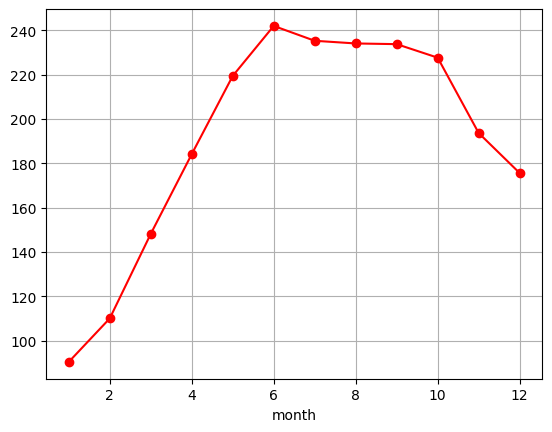

In [73]:
monthly_avg.plot(
    kind='line',
    marker='o',
    color='red',
    grid=True
)



([<matplotlib.axis.XTick at 0x7e18eddc6490>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

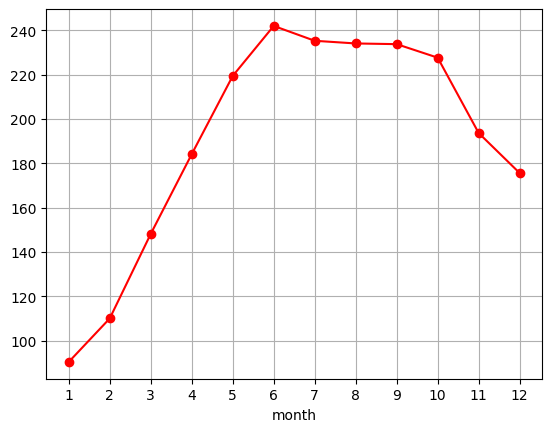

In [75]:
monthly_avg.plot(
    kind='line',
    marker='o',
    color='red',
    grid=True
)
plt.xticks(range(1, 13))

1. В які місяці спостерігається пік та спад оренди? - Пік оренди спостерігається в червні, а спад від жовтня до кінця року. Найнижчий показник спостерігається в січні.
2. Чи збігається ця закономірність з результатами з попереднього завдання? -  Закономірність зберігається, оскільки протягом трьох місяців третього кварталу показники були на високому рівні. Хоч і найвищий показник був в червні, в другому кварталі середня кількість оренди нижча, через низькі показники оренди в квітні і травні.
3. Як може вплинути клімат на оренду велосипедів протягом року? - Клімат є одним з найважливіших чинників, які можуть впливати на оренду, оскільки як вітер, дощ, туман так і аномальна спека можуть знизити попит на велосипеди.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [81]:
weather_counts = df['weather'].value_counts().sort_index()

In [82]:
weather_counts

,count
weather,
1,7192
2,2834
3,859
4,1


In [83]:
weather_counts.index = [
    'Ясно',
    'Туман',
    'Легкий дощ',
    'Сильний дощ'
]

In [79]:
weather_counts

,count
Ясно,1476063
Туман,507160
Легкий дощ,102089
Сильний дощ,164


<Axes: ylabel='count'>

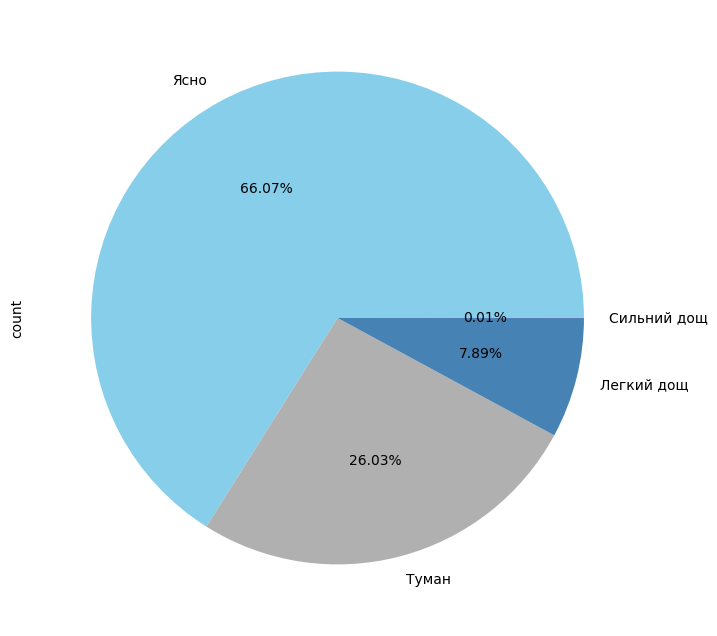

In [85]:
weather_counts.plot(
    kind='pie',
    autopct='%1.2f%%',
    colors=['#87CEEB', '#B0B0B0', '#4682B4', '#4B0082'],
    figsize=(8, 8)
)

Очікуваний результат:

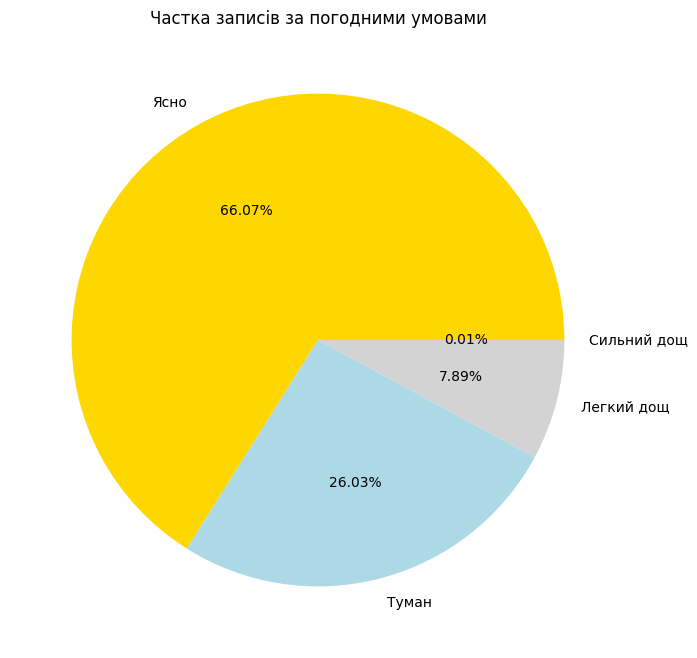

1. Яка погода переважає в датасеті? - В датасеті переважає ясна погода (66.07%).
2. Чи є дні із сильним дощем? Яка їх частка?- Днів із сильним дощем в датасеті було 164, а це дуже незначна частка (0.01%).
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів? - Оренда велосипедів в ясні дні вища ніж в дні з дощем чи туманом.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

<Axes: title={'center': 'count'}, ylabel='weather'>

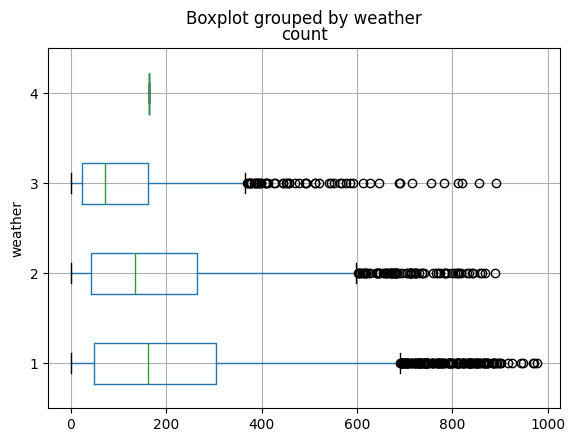

In [86]:
df.boxplot(
    column='count',
    by='weather',
    vert=False
)

([<matplotlib.axis.YTick at 0x7e18ee2bde50>,
 [Text(0, 1, 'Ясно'),
  Text(0, 2, 'Туман'),
  Text(0, 3, 'Легкий дощ'),
  Text(0, 4, 'Сильний дощ')])

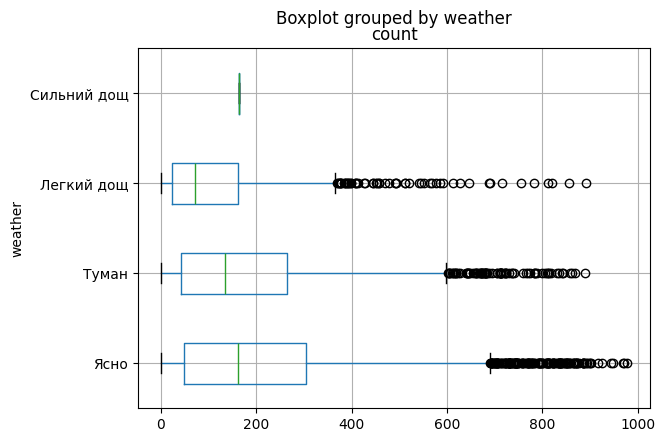

In [89]:
df.boxplot(
    column='count',
    by='weather',
    vert=False
)
plt.yticks(
    [1, 2, 3, 4],
    ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
)


1. При якій погоді найбільший розкид у кількості оренди? -  Найбільший розкид кількості оренд спостерігається при ясній погоді
2. Чи є викиди (outliers) в даних? При якій погоді? - Викиди присутні при ясній погоді, тумані та легкому дощі.
3. При якій погоді медіанне значення оренди найвище? - Найвище медіанне значення оренди спостерігається при ясній погоді.

Кількість оренд велосипедів суттєво залежить від погодних умов. Найвища типова кількість оренд спостерігається за ясної погоди,  нижча - під час туману. При легкому дощі медіанна кількість оренд значно зменшується. Для сильного дощу спостережень дуже мало, тому робити надійні висновки складно. Велика кількість викидів у всіх категоріях свідчить про наявність періодів із нетипово високою кількістю оренд.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

In [ ]:
colors =

<Axes: title={'center': 'Залежність температури від кількості оренд'}, xlabel='Температура', ylabel='Кількість оренд'>

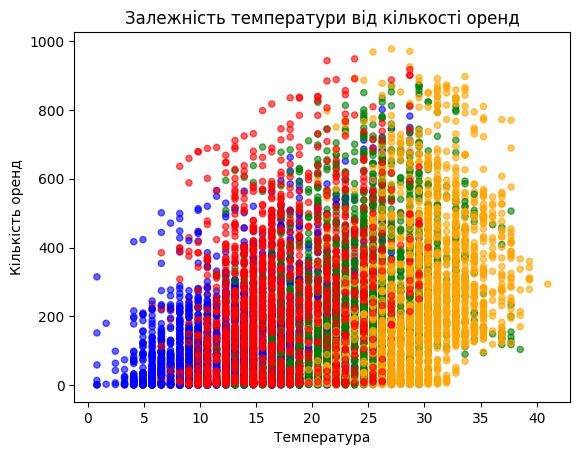

In [96]:
df.plot(
    kind='scatter',
    x='temp',
    y='count',
    alpha=0.6,
    c=df['season'].map({
        1: 'blue',
        2: 'green',
        3: 'orange',
        4: 'red'
    }),
    title='Залежність температури від кількості оренд',
    xlabel='Температура',
    ylabel='Кількість оренд'
)

Чи є зв'язок між температурою та кількістю оренди? Який? - Кількість орендованих велосипедів вища в діапазоні температури від 10 до 35. Там де температура нижча 10 або вища 35 кількість оренди значно менша.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

<Axes: title={'center': 'Середня кількість оренд за днями тижня'}, xlabel='День тижня', ylabel='Середня кількість оренд'>

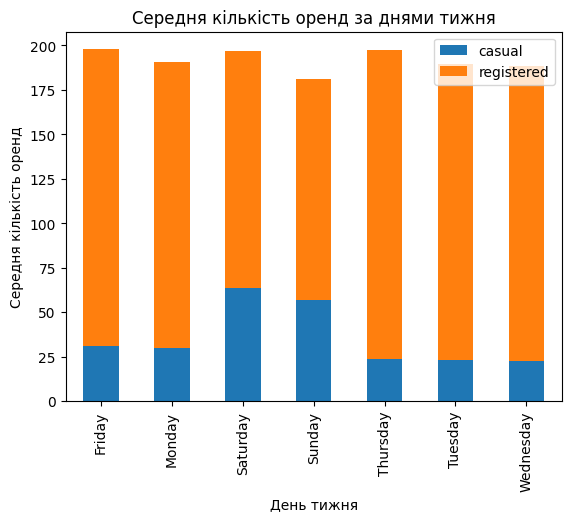

In [99]:
df.groupby('weekday')[['casual', 'registered']].mean().plot(
    kind='bar',
    stacked=True,
    title='Середня кількість оренд за днями тижня',
    xlabel='День тижня',
    ylabel='Середня кількість оренд'
)


1. В які дні тижня більше оренд від зареєстрованих користувачів? - Найбільша кількість оренд від зареєстрованих користувачів в будні дні.
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня? - Більша кількість оренди в будні дні може означати, що користувачі орендують велосипеди, щоб доїжджати до роботи або школи.